##### ARTI 560 - Computer Vision

## Image Classification with Vision Transformer (ViT) - Exercise

### Objective

In this exercise, you will test the pretrained Vision Transformer (ViT) model on 5 real-world images that you find online.

You will:

1. Download 5 images for different classes in [ImageNet](https://github.com/Waikato/wekaDeeplearning4j/blob/master/docs/user-guide/class-maps/IMAGENET.md).

2. Load the ImageNet class names from a [text file](https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt).

3. Use ViT to predict the class for each image.

4. Record whether the prediction was correct.

#### Important Note

For this exercise, you MUST use the following KerasHub components:

- [keras_hub.models.ViTImageClassifier](https://keras.io/keras_hub/api/models/vit/vit_image_classifier/)

- [keras_hub.models.ViTImageClassifierPreprocessor](https://keras.io/keras_hub/api/models/vit/vit_image_classifier_preprocessor/)

This ensures your input preprocessing (resizing + normalization) matches what the pretrained ViT model expects.

Do not replace the preprocessor with manual normalization (such as dividing by 255), because it may produce incorrect predictions.

____________________________________

I picked these images:
1.  850	teddy, teddy bear
2.  331	hare
3.  417	balloon
4.  507	combination lock
5. 551	face powder


In [1]:
# Import Libraries
import tensorflow as tf
from tensorflow import keras
from keras import layers
import keras_hub #provides pretrained models like: ViT, Bert
#import tensorflow_datasets as tfds
import numpy as np


# Load ViTImageClassifierPreprocessor (vit_base_patch16_224_imagenet preset)


# Load ViTImageClassifier (vit_base_patch16_224_imagenet preset)


# Load the images


# Predict classes


2026-03-06 00:56:23.970750: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/opt/anaconda3/envs/vit_lab/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load ViTImageClassifierPreprocessor (vit_base_patch16_224_imagenet preset)
preprocessor = keras_hub.models.ViTImageClassifierPreprocessor.from_preset(
        "vit_base_patch16_224_imagenet")

100%|██████████| 698/698 [00:00<00:00, 403kB/s]


100%|██████████| 1.74k/1.74k [00:00<00:00, 1.16MB/s]


In [3]:
# Load ViTImageClassifier (vit_base_patch16_224_imagenet preset)
classifier = keras_hub.models.ViTImageClassifier.from_preset(
    "vit_base_patch16_224_imagenet"
)


100%|██████████| 3.46k/3.46k [00:00<00:00, 400kB/s]


100%|██████████| 331M/331M [00:17<00:00, 20.1MB/s] 


100%|██████████| 328M/328M [00:17<00:00, 19.9MB/s] 


In [4]:
# Load the ImageNet class names from a text file
import requests

url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
labels = requests.get(url).text.strip().split("\n") 

Below, I loaded each image and predicted the top 5 classes:

In [5]:
from PIL import Image
import numpy as np
from IPython.display import display

def predict_image(path):
    img = Image.open(path).convert("RGB")
    display(img)

    x = tf.convert_to_tensor(np.array(img))           # (H,W,3)
    x = tf.cast(x, tf.float32)
    x = tf.expand_dims(x, axis=0)                     # (1,H,W,3)

    processed = preprocessor(x, training=False)
    logits = classifier(processed, training=False)    

    probs = tf.nn.softmax(logits, axis=-1).numpy()[0]
    top5 = probs.argsort()[-5:][::-1]

    print("Top-1:", labels[int(top5[0])], probs[top5[0]])
    for i in top5:
        print(labels[int(i)], probs[i])

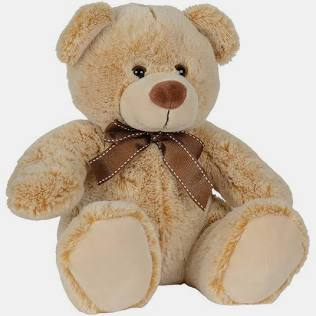

Top-1: teddy 0.95552623
teddy 0.95552623
toyshop 0.0025627138
backpack 0.00083179574
seat belt 0.0007650627
velvet 0.0006720104


In [6]:
predict_image("teddy bear.jpeg")

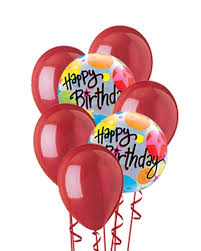

Top-1: balloon 0.5783002
balloon 0.5783002
maraca 0.18312253
ping-pong ball 0.14269705
punching bag 0.03452261
baseball 0.0064158854


In [7]:
predict_image("balloon.jpeg")

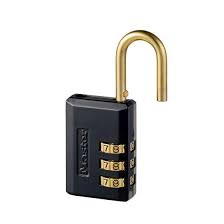

Top-1: combination lock 0.9995332
combination lock 0.9995332
padlock 0.00033048404
safe 3.682741e-05
chain 7.0021138e-06
hook 2.744932e-06


In [8]:
predict_image("combination lock.jpeg")

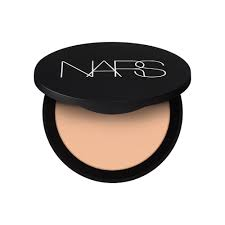

Top-1: face powder 0.9976527
face powder 0.9976527
lipstick 0.0002803253
sunscreen 0.00021158266
sunglass 0.00011168641
perfume 5.1530387e-05


In [9]:
predict_image("face powder.jpeg")

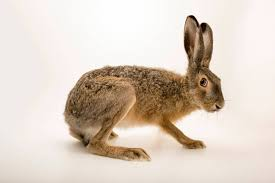

Top-1: hare 0.9904206
hare 0.9904206
wood rabbit 0.009149511
Angora 4.925742e-05
fox squirrel 1.0781381e-05
kit fox 8.277274e-06


In [10]:
predict_image("hare.jpeg")

### Record Your Results

Fill the table below based on your results:

| Image File   | Predicted Label | True Label (What you searched) | Correct? (Yes/No) |
| ------------ | --------------- | ------------------------------ | ----------------- |
|teddy bear.jpeg| teddy   |teddy, teddy bear| Yes     |
|balloon.jpeg|balloon|balloon|Yes|
|combination lock.jpeg|combination lock|combination lock|Yes|
| face powder.jpeg | face powder |face powder | Yes |
| hare.jpeg | hare | hare | Yes |
